# Installation

In [ ]:
%pip install kaggle

In [ ]:
%pip install matplotlib

In [ ]:
%pip install pandas

In [ ]:
%pip install numpy

# Dealing with kaggle.json

In [ ]:
%mkdir ~/.kaggle

Download kaggle.json first from your Kaggle account!

In [ ]:
%cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 /root/.kaggle/kaggle.json

# Downloading Files

In [ ]:
! kaggle datasets download ankushpanday1/lung-cancer-risk-and-trends-across-25-countries

Dataset URL: https://www.kaggle.com/datasets/ankushpanday1/lung-cancer-risk-and-trends-across-25-countries
License(s): MIT


In [ ]:
! cp /lung-cancer-risk-and-trends-across-25-countries.zip /content/.

cp: cannot stat '/lung-cancer-risk-and-trends-across-25-countries.zip': No such file or directory


In [ ]:
from zipfile import ZipFile
with ZipFile("lung-cancer-risk-and-trends-across-25-countries.zip", 'r') as zObject:

    # Extracting all the members of the zip
    # into a specific location.
    zObject.extractall(
        path="/content/sample_data")

In [ ]:
%cd sample_data

/content/sample_data


# Coding Portion and Describing Data

In [ ]:
import pandas as pds
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from imblearn.over_sampling import SMOTE
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython.core.pylabtools")

In [ ]:
df = pds.read_csv("lung_cancer_prediction_dataset.csv")
print(df.head())

   ID       Country  Population_Size  Age  Gender Smoker  Years_of_Smoking  \
0   0         China             1400   80    Male    Yes                30   
1   1          Iran               84   53    Male     No                 0   
2   2        Mexico              128   47    Male    Yes                12   
3   3     Indonesia              273   39  Female     No                 0   
4   4  South Africa               59   44  Female     No                 0   

   Cigarettes_per_Day Passive_Smoker Family_History  ...  \
0                  29             No             No  ...   
1                   0            Yes             No  ...   
2                   6            Yes             No  ...   
3                   0             No            Yes  ...   
4                   0            Yes             No  ...   

  Air_Pollution_Exposure Occupational_Exposure  Indoor_Pollution  \
0                    Low                   Yes                No   
1                    Low          

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220632 entries, 0 to 220631
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID                           220632 non-null  int64  
 1   Country                      220632 non-null  object 
 2   Population_Size              220632 non-null  int64  
 3   Age                          220632 non-null  int64  
 4   Gender                       220632 non-null  object 
 5   Smoker                       220632 non-null  object 
 6   Years_of_Smoking             220632 non-null  int64  
 7   Cigarettes_per_Day           220632 non-null  int64  
 8   Passive_Smoker               220632 non-null  object 
 9   Family_History               220632 non-null  object 
 10  Lung_Cancer_Diagnosis        220632 non-null  object 
 11  Cancer_Stage                 8961 non-null    object 
 12  Survival_Years               220632 non-null  int64  
 13 

In [ ]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['Country'].unique()

array(['China', 'Iran', 'Mexico', 'Indonesia', 'South Africa', 'India',
       'Myanmar', 'Ethiopia', 'Nigeria', 'Egypt', 'Italy', 'France',
       'Germany', 'Brazil', 'Turkey', 'Thailand', 'Japan', 'Pakistan',
       'Philippines', 'Bangladesh', 'Russia', 'Vietnam', 'USA',
       'DR Congo', 'UK'], dtype=object)

In [ ]:
df['Developed_or_Developing'].unique()

array(['Developing', 'Developed'], dtype=object)

In [ ]:
df['Age'].unique()

array([80, 53, 47, 39, 44, 54, 60, 74, 32, 29, 45, 79, 71, 59, 64, 81, 51,
       34, 72, 84, 25, 75, 40, 77, 20, 41, 55, 33, 24, 36, 68, 30, 70, 27,
       28, 83, 66, 78, 82, 58, 67, 52, 57, 61, 31, 76, 62, 63, 42, 50, 85,
       38, 69, 23, 49, 48, 73, 37, 46, 21, 65, 22, 26, 43, 35, 56])

In [ ]:
df.describe(include='object').T

,count,unique,top,freq
Country,220632,25,Japan,8989
Gender,220632,2,Female,110488
Smoker,220632,2,No,132291
Passive_Smoker,220632,2,No,154670
Family_History,220632,2,No,187807
Lung_Cancer_Diagnosis,220632,2,No,211671
Cancer_Stage,8961,4,Stage 4,2387
Adenocarcinoma_Type,220632,2,No,121139
Air_Pollution_Exposure,220632,3,Medium,110157
Occupational_Exposure,220632,2,No,154115


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,220632.0,110315.500000,63691.116633,0.0,55157.75,110315.5,165473.25,220631.0
Population_Size,220632.0,229.779882,349.247477,54.0,83.00,113.0,206.00,1400.0
Age,220632.0,52.518352,19.078215,20.0,36.00,53.0,69.00,85.0
Years_of_Smoking,220632.0,8.175274,12.377248,0.0,0.00,0.0,15.00,40.0
Cigarettes_per_Day,220632.0,7.007515,9.802187,0.0,0.00,0.0,14.00,30.0
Survival_Years,220632.0,0.223526,1.231025,0.0,0.00,0.0,0.00,10.0
Annual_Lung_Cancer_Deaths,220632.0,63931.086928,130690.126777,10005.0,23000.00,30000.0,45000.00,690000.0
Lung_Cancer_Prevalence_Rate,220632.0,1.502085,0.578043,0.5,1.00,1.5,2.00,2.5
Mortality_Rate,220632.0,3.049802,14.924169,0.0,0.00,0.0,0.00,90.0


# **Subquestion 1**

**How do demographic factors (eg. age, gender, country, etc.) influence the likelihood of lung cancer diagnosis?**

1.   Country's Economic Status
2.   Age with Age Groups
3.   Gender



# Analyzing the Dataset

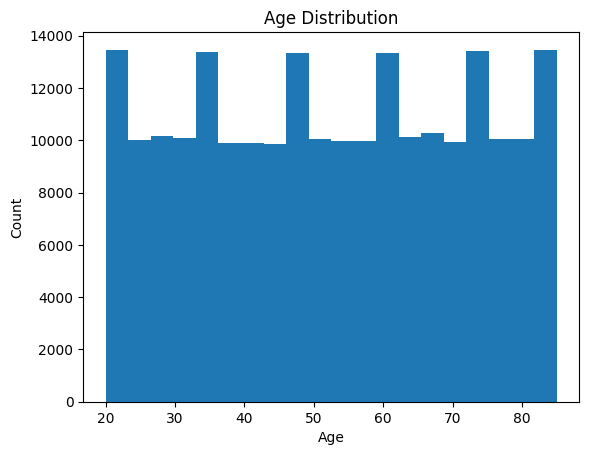

In [ ]:
# Age Analysis of the Dataset
plt.hist(df['Age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

Filtering the columns to focus on the demographic-related columns.

In [ ]:
# Category List
category_columns = ['Country',
                    'Age',
                    'Gender',
                    'Lung_Cancer_Diagnosis',
                    'Developed_or_Developing',
                    'Lung_Cancer_Prevalence_Rate' #For Country-related analysis
                    ]
length_columns = len(category_columns)

# Replacing df
df = df[category_columns]
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220632 entries, 0 to 220631
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      220632 non-null  object 
 1   Population_Size              220632 non-null  int64  
 2   Age                          220632 non-null  int64  
 3   Gender                       220632 non-null  object 
 4   Lung_Cancer_Diagnosis        220632 non-null  object 
 5   Developed_or_Developing      220632 non-null  object 
 6   Lung_Cancer_Prevalence_Rate  220632 non-null  float64
dtypes: float64(1), int64(2), object(4)
memory usage: 11.8+ MB


,Population_Size,Age,Lung_Cancer_Prevalence_Rate
count,220632.000000,220632.000000,220632.000000
mean,229.779882,52.518352,1.502085
std,349.247477,19.078215,0.578043
min,54.000000,20.000000,0.500000
25%,83.000000,36.000000,1.000000
50%,113.000000,53.000000,1.500000
75%,206.000000,69.000000,2.000000
max,1400.000000,85.000000,2.500000


# EDA Portion: Country and Economic Status

In [ ]:
df['Lung_Cancer_Diagnosis_Binary'] = df['Lung_Cancer_Diagnosis'].map({'Yes': 1, 'No': 0})
df['Lung_Cancer_Diagnosis_Binary'].value_counts()

,count
Lung_Cancer_Diagnosis_Binary,
0,211671
1,8961


In [ ]:
# Country Analysis
country_analysis = df.groupby(['Country', 'Developed_or_Developing']).agg({'Lung_Cancer_Diagnosis_Binary': 'mean', 'Lung_Cancer_Prevalence_Rate': 'mean'})
# Sort by diagnosis rate for better readability
country_analysis = country_analysis.sort_values(by='Lung_Cancer_Diagnosis_Binary', ascending=False)
print(country_analysis)

                                      Lung_Cancer_Diagnosis_Binary  \
Country      Developed_or_Developing                                 
Ethiopia     Developing                                   0.045571   
Japan        Developed                                    0.044276   
Turkey       Developing                                   0.043275   
USA          Developed                                    0.042992   
Nigeria      Developing                                   0.042700   
Myanmar      Developing                                   0.042295   
Italy        Developed                                    0.042263   
Egypt        Developing                                   0.042054   
Indonesia    Developing                                   0.041728   
DR Congo     Developing                                   0.041079   
Bangladesh   Developing                                   0.040925   
France       Developed                                    0.040919   
UK           Develop


Lung Cancer Diagnosis and Prevalence by Top 10 Countries:

| Country    |   Diagnosis_Yes |   Diagnosis_No |   Prevalence_Rate_Mean |   %_Diagnosis_Yes |
|:-----------|----------------:|---------------:|-----------------------:|------------------:|
| Bangladesh |             361 |           8460 |                   1.5  |              4.09 |
| Brazil     |             353 |           8447 |                   1.51 |              4.01 |
| China      |             338 |           8569 |                   1.5  |              3.79 |
| India      |             335 |           8417 |                   1.51 |              3.83 |
| Indonesia  |             366 |           8405 |                   1.51 |              4.17 |
| Mexico     |             336 |           8501 |                   1.5  |              3.8  |
| Nigeria    |             377 |           8452 |                   1.51 |              4.27 |
| Pakistan   |             346 |           8377 |                   1.5  |           

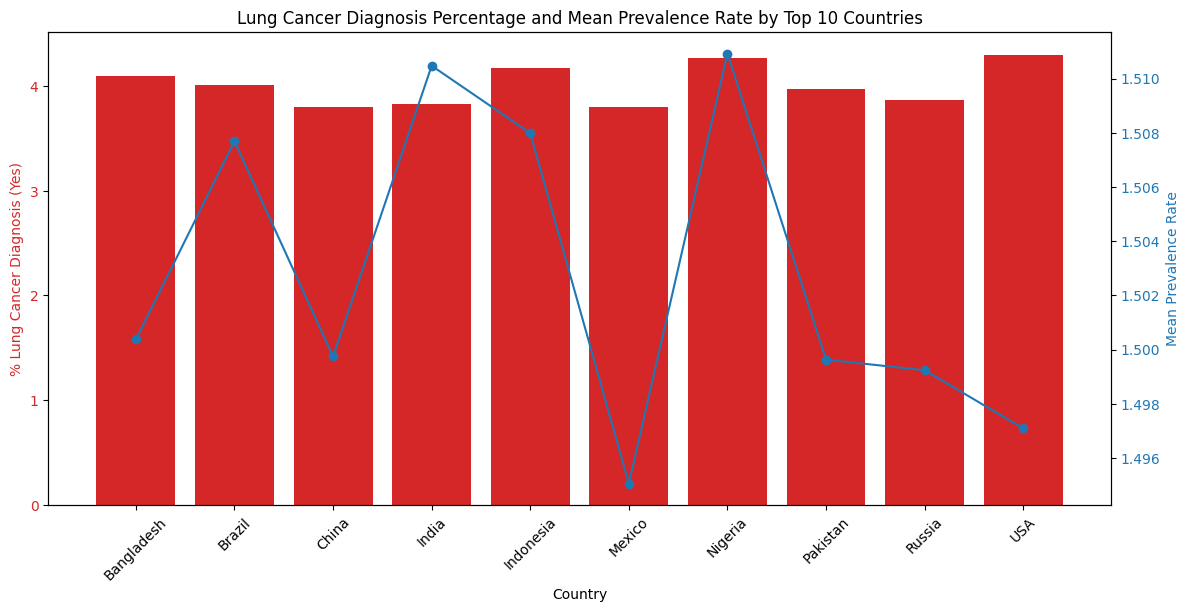

In [ ]:
# 1. Table and Visualization: Lung Cancer Diagnosis and Prevalence by Country (Top N)

# Get the top N countries by population size (you can adjust N)
top_n = 10
top_countries = df.groupby('Country')['Population_Size'].max().nlargest(top_n).index
df_top_countries = df[df['Country'].isin(top_countries)].copy()

# Table by Country
country_summary = df_top_countries.groupby('Country').agg(
    Diagnosis_Yes=('Lung_Cancer_Diagnosis', lambda x: (x == 'Yes').sum()),
    Diagnosis_No=('Lung_Cancer_Diagnosis', lambda x: (x == 'No').sum()),
    Prevalence_Rate_Mean=('Lung_Cancer_Prevalence_Rate', 'mean')
).reset_index()
country_summary['%_Diagnosis_Yes'] = (country_summary['Diagnosis_Yes'] / (country_summary['Diagnosis_Yes'] + country_summary['Diagnosis_No'])) * 100
print("\nLung Cancer Diagnosis and Prevalence by Top {} Countries:\n".format(top_n))
print(country_summary.round(2).to_markdown(index=False))

# Visualization by Country
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Country')
ax1.set_ylabel('% Lung Cancer Diagnosis (Yes)', color=color)
ax1.bar(country_summary['Country'], country_summary['%_Diagnosis_Yes'], color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Mean Prevalence Rate', color=color)
ax2.plot(country_summary['Country'], country_summary['Prevalence_Rate_Mean'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label might be slightly clipped
plt.title('Lung Cancer Diagnosis Percentage and Mean Prevalence Rate by Top {} Countries'.format(top_n))
plt.show()



Lung Cancer Diagnosis and Prevalence by Economic Status:

| Developed_or_Developing   |   Diagnosis_Yes |   Diagnosis_No |   Prevalence_Rate_Mean |   %_Diagnosis_Yes |
|:--------------------------|----------------:|---------------:|-----------------------:|------------------:|
| Developed                 |            2195 |          50696 |                    1.5 |              4.15 |
| Developing                |            6766 |         160975 |                    1.5 |              4.03 |


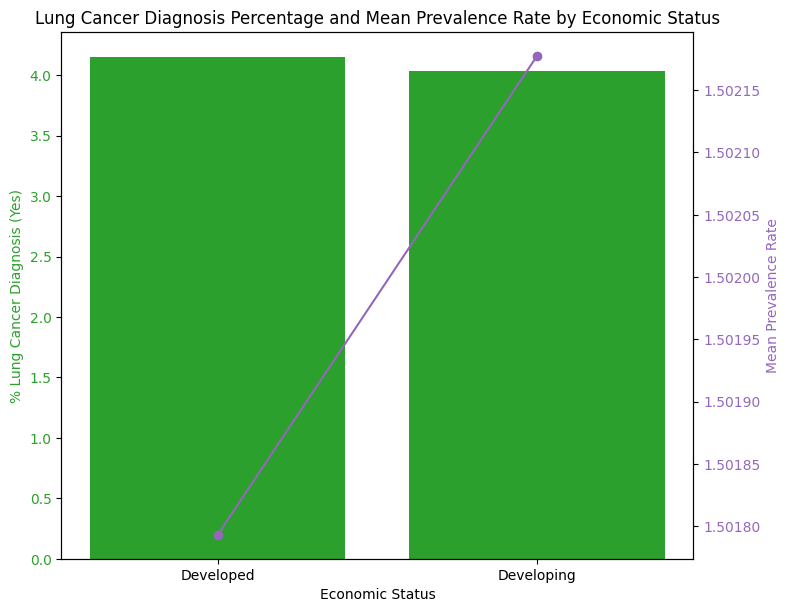

In [ ]:
# 2. Table and Visualization: Lung Cancer Diagnosis and Prevalence by Economic Status

# Table by Economic Status
economic_summary = df.groupby('Developed_or_Developing').agg(
    Diagnosis_Yes=('Lung_Cancer_Diagnosis', lambda x: (x == 'Yes').sum()),
    Diagnosis_No=('Lung_Cancer_Diagnosis', lambda x: (x == 'No').sum()),
    Prevalence_Rate_Mean=('Lung_Cancer_Prevalence_Rate', 'mean')
).reset_index()
economic_summary['%_Diagnosis_Yes'] = (economic_summary['Diagnosis_Yes'] / (economic_summary['Diagnosis_Yes'] + economic_summary['Diagnosis_No'])) * 100
print("\nLung Cancer Diagnosis and Prevalence by Economic Status:\n")
print(economic_summary.round(2).to_markdown(index=False))

# Visualization by Economic Status
fig, ax1 = plt.subplots(figsize=(8, 6))

color = 'tab:green'
ax1.set_xlabel('Economic Status')
ax1.set_ylabel('% Lung Cancer Diagnosis (Yes)', color=color)
ax1.bar(economic_summary['Developed_or_Developing'], economic_summary['%_Diagnosis_Yes'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:purple'
ax2.set_ylabel('Mean Prevalence Rate', color=color)
ax2.plot(economic_summary['Developed_or_Developing'], economic_summary['Prevalence_Rate_Mean'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Lung Cancer Diagnosis Percentage and Mean Prevalence Rate by Economic Status')
plt.show()

# EDA Portion: Gender and Age of Diagnosed

In [ ]:
# Filter the DataFrame to include only those diagnosed with lung cancer
df_diagnosed = df[df['Lung_Cancer_Diagnosis'] == 'Yes'].copy()

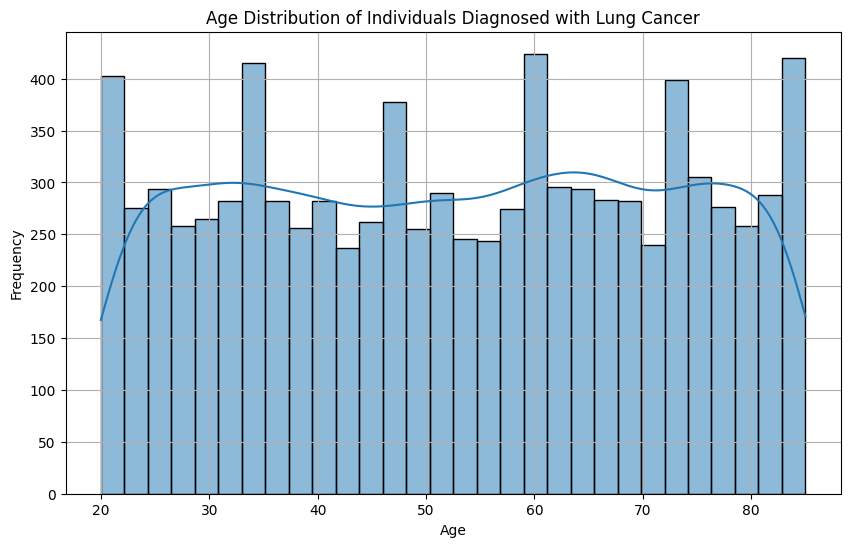


Summary Statistics for Age of Individuals Diagnosed with Lung Cancer:
|       |       Age |
|:------|----------:|
| count | 8961      |
| mean  |   52.6647 |
| std   |   19.1765 |
| min   |   20      |
| 25%   |   36      |
| 50%   |   53      |
| 75%   |   69      |
| max   |   85      |


In [ ]:
# 1. Age Distribution of Diagnosed Individuals
plt.figure(figsize=(10, 6))
sns.histplot(df_diagnosed['Age'], bins=30, kde=True)
plt.title('Age Distribution of Individuals Diagnosed with Lung Cancer')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Summary statistics for age of diagnosed individuals
print("\nSummary Statistics for Age of Individuals Diagnosed with Lung Cancer:")
print(df_diagnosed['Age'].describe().to_markdown())

<ipython-input-25-982e97a2434c>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis')


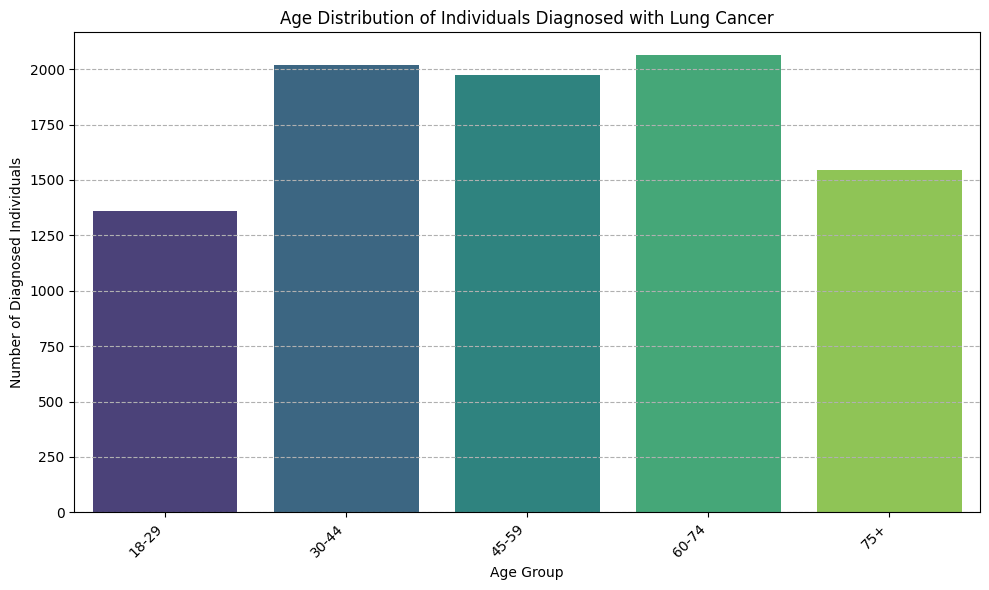


Number of Diagnosed Individuals by Age Group:
| Age Group   |   Count |
|:------------|--------:|
| 18-29       |    1358 |
| 30-44       |    2020 |
| 45-59       |    1973 |
| 60-74       |    2063 |
| 75+         |    1547 |


In [ ]:
# Dealing with Age Groups
bins = [0, 18, 30, 45, 60, 75, 100]
labels = ['0-17', '18-29', '30-44', '45-59', '60-74', '75+']
df['Age_Group'] = pds.cut(df['Age'], bins=bins, labels=labels, right=False)

# Define age groups
bins = [18, 30, 45, 60, 75, 100]
labels = ['18-29', '30-44', '45-59', '60-74', '75+']
df_diagnosed['Age_Group'] = pds.cut(df_diagnosed['Age'], bins=bins, labels=labels, right=False)

# Count the number of diagnosed individuals in each age group
age_group_counts = df_diagnosed['Age_Group'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis')
plt.title('Age Distribution of Individuals Diagnosed with Lung Cancer')
plt.xlabel('Age Group')
plt.ylabel('Number of Diagnosed Individuals')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Optional: Print the counts in a table
age_group_table = pds.DataFrame({
    'Age Group': age_group_counts.index,
    'Count': age_group_counts.values
})
print("\nNumber of Diagnosed Individuals by Age Group:")
print(age_group_table.to_markdown(index=False))

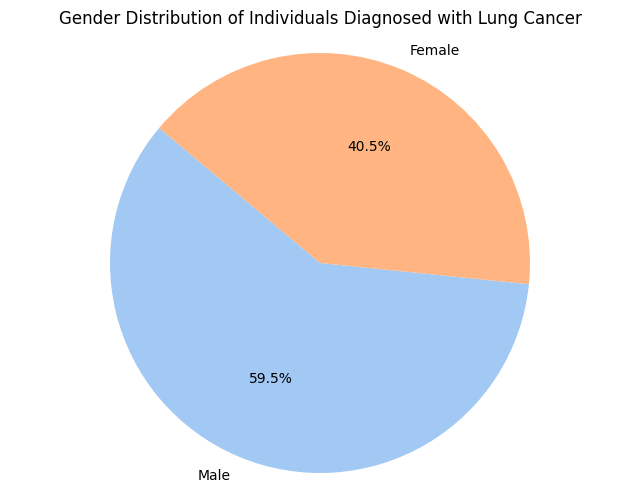


Gender Distribution of Individuals Diagnosed with Lung Cancer:
| Gender   |   Count |   Percentage |
|:---------|--------:|-------------:|
| Male     |    5332 |         59.5 |
| Female   |    3629 |         40.5 |


In [ ]:
# Gender Distribution of Diagnosed Individuals
gender_counts = df_diagnosed['Gender'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Gender Distribution of Individuals Diagnosed with Lung Cancer')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Table of gender distribution
gender_df = pds.DataFrame({'Gender': gender_counts.index, 'Count': gender_counts.values})
gender_df['Percentage'] = (gender_df['Count'] / gender_df['Count'].sum()) * 100
print("\nGender Distribution of Individuals Diagnosed with Lung Cancer:")
print(gender_df.round(2).to_markdown(index=False))

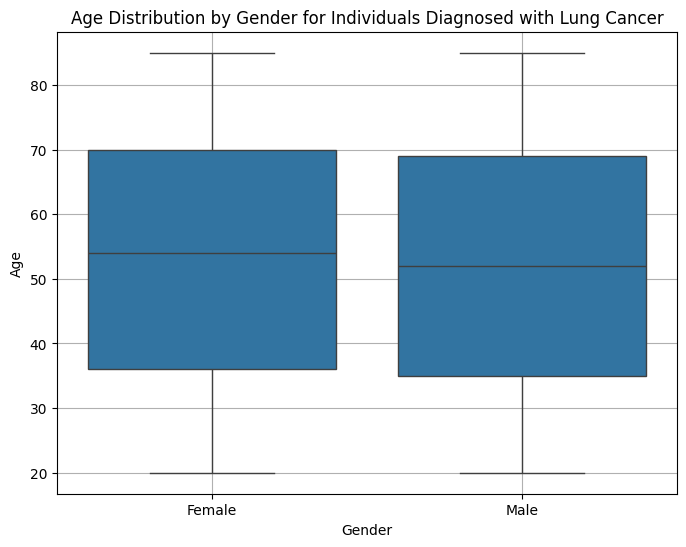


Summary Statistics of Age by Gender for Individuals Diagnosed with Lung Cancer:
| Gender   |   count |    mean |     std |   min |   25% |   50% |   75% |   max |
|:---------|--------:|--------:|--------:|------:|------:|------:|------:|------:|
| Female   |    3629 | 53.1607 | 19.2942 |    20 |    36 |    54 |    70 |    85 |
| Male     |    5332 | 52.3271 | 19.0905 |    20 |    35 |    52 |    69 |    85 |


In [ ]:
# 3. Age Distribution by Gender for Diagnosed Individuals (Box Plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Age', data=df_diagnosed)
plt.title('Age Distribution by Gender for Individuals Diagnosed with Lung Cancer')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.grid(True)
plt.show()

# Summary statistics of age by gender for diagnosed individuals
print("\nSummary Statistics of Age by Gender for Individuals Diagnosed with Lung Cancer:")
print(df_diagnosed.groupby('Gender')['Age'].describe().to_markdown())

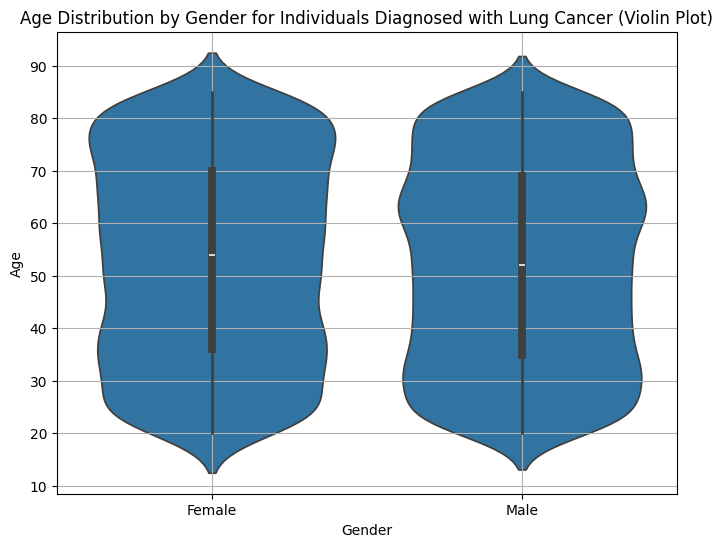

In [ ]:
# 4. Age Distribution by Gender for Diagnosed Individuals (Violin Plot)
plt.figure(figsize=(8, 6))
sns.violinplot(x='Gender', y='Age', data=df_diagnosed)
plt.title('Age Distribution by Gender for Individuals Diagnosed with Lung Cancer (Violin Plot)')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.grid(True)
plt.show()

# EDA (weighted by Population Size)

In terms of comparison specifics, they're the same so I don't think this is applicable in the paper

<ipython-input-26-50c3802f6c7a>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diagnosed_population_by_age = df_diagnosed.groupby('Age_Group')['Population_Size'].sum()
<ipython-input-26-50c3802f6c7a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=diagnosed_population_by_age.index, y=diagnosed_population_by_age.values, palette='Oranges_r')


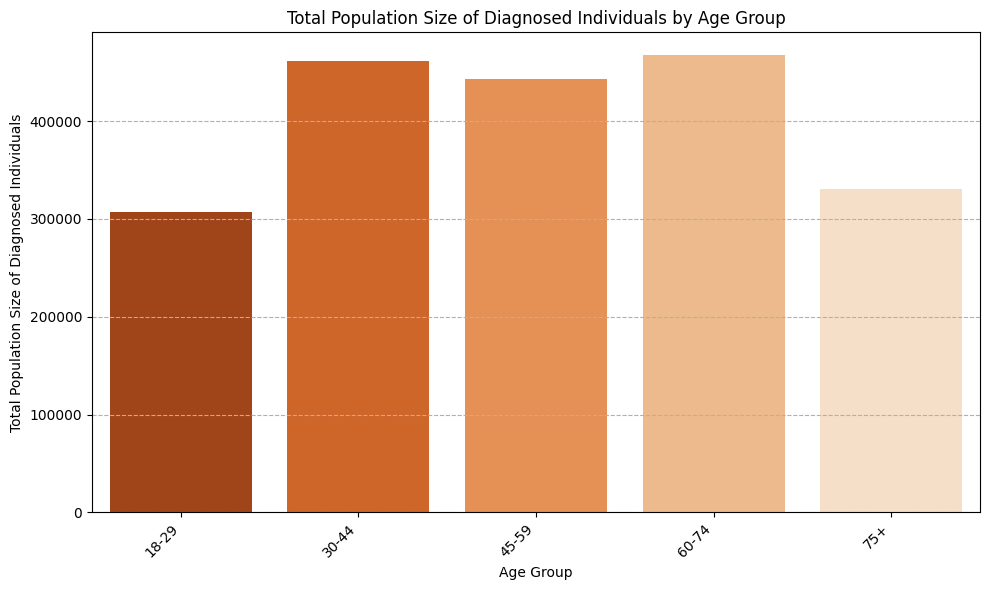


Total Population Size of Diagnosed Individuals by Age Group:
| Age Group   |   Total Population Size (Diagnosed) |
|:------------|------------------------------------:|
| 18-29       |                              307427 |
| 30-44       |                              460893 |
| 45-59       |                              443304 |
| 60-74       |                              467310 |
| 75+         |                              330130 |


In [ ]:
# 2. Number of Diagnosed Individuals (Weighted by Population Size) by Age Group
diagnosed_population_by_age = df_diagnosed.groupby('Age_Group')['Population_Size'].sum()

plt.figure(figsize=(10, 6))
sns.barplot(x=diagnosed_population_by_age.index, y=diagnosed_population_by_age.values, palette='Oranges_r')
plt.title('Total Population Size of Diagnosed Individuals by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Population Size of Diagnosed Individuals')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

diagnosed_population_table = pds.DataFrame({
    'Age Group': diagnosed_population_by_age.index,
    'Total Population Size (Diagnosed)': diagnosed_population_by_age.values
})
print("\nTotal Population Size of Diagnosed Individuals by Age Group:")
print(diagnosed_population_table.to_markdown(index=False))